# Brain Tumor Detection using CNN (MRI Images)

This notebook trains a **Convolutional Neural Network (CNN)** that looks at a brain MRI image and decides whether it shows a **tumor** or **no tumor**.

**Dataset:** *Brain MRI Images for Brain Tumor Detection* (Kaggle, by Navoneel Chakrabarty), the same dataset used in the reference notebook.

- 253 MRI images in total
- `yes` folder: **155** images with a tumor
- `no` folder: **98** images without a tumor
- Images have different sizes and colour formats (some colour, some grayscale)

**Folder structure needed:**
```
brain_tumor_dataset/
    yes/   (MRI images with tumor)
    no/    (MRI images without tumor)
```
Download it from Kaggle (search "Brain MRI Images for Brain Tumor Detection"), unzip it, and put the `yes` and `no` folders inside a folder called `brain_tumor_dataset` next to this notebook.

**Problem type:** binary image classification (2 classes).

> **Note:** This project is for learning only. It is **not** a medical tool and must never be used to diagnose a real patient.

## 1. Import Libraries
We import the libraries for file handling, data splitting, building the CNN, plotting graphs and measuring results.

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# Fix the random seed so the results are (nearly) the same every time we run
tf.keras.utils.set_random_seed(42)

no: 98 images
yes: 155 images


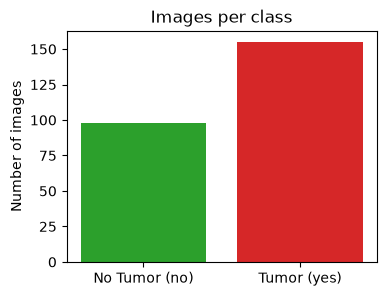

In [2]:
data_dir = 'brain_tumor_dataset'          # folder that contains the 'yes' and 'no' folders
img_exts = ('.jpg', '.jpeg', '.png')       # image file types we accept

counts = {}
for cls in ['no', 'yes']:
    folder = os.path.join(data_dir, cls)
    counts[cls] = len([f for f in os.listdir(folder) if f.lower().endswith(img_exts)])
    print(f"{cls}: {counts[cls]} images")

plt.figure(figsize=(4, 3))
plt.bar(['No Tumor (no)', 'Tumor (yes)'], [counts['no'], counts['yes']], color=['tab:green', 'tab:red'])
plt.title('Images per class')
plt.ylabel('Number of images')
plt.show()

The loop opens the `no` and `yes` folders and counts only real image files.

The bar chart shows the classes are **not equal**: there are more tumor images (155) than no-tumor images (98). This is called *class imbalance*. We will handle it later using class weights.

In [3]:
split_dir = 'dataset_split'

# Start fresh if we ran this cell before
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

for cls in ['no', 'yes']:
    files = sorted(f for f in os.listdir(os.path.join(data_dir, cls)) if f.lower().endswith(img_exts))

    # 70% train, 30% left over
    train_files, temp_files = train_test_split(files, test_size=0.30, random_state=42)
    # split the 30% in half -> 15% validation, 15% test
    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=42)

    for split_name, split_files in [('train', train_files), ('val', val_files), ('test', test_files)]:
        out_folder = os.path.join(split_dir, split_name, cls)
        os.makedirs(out_folder, exist_ok=True)
        for f in split_files:
            shutil.copy(os.path.join(data_dir, cls, f), os.path.join(out_folder, f))

# Show how many images ended up in each group
for split_name in ['train', 'val', 'test']:
    n_no = len(os.listdir(os.path.join(split_dir, split_name, 'no')))
    n_yes = len(os.listdir(os.path.join(split_dir, split_name, 'yes')))
    print(f"{split_name:5s} -> no: {n_no:3d} | yes: {n_yes:3d}")

train -> no:  68 | yes: 108
val   -> no:  15 | yes:  23
test  -> no:  15 | yes:  24


`train_test_split` randomly picks which files go where (`random_state=42` keeps it repeatable). The files are **copied** into a new folder `dataset_split/` with `train`, `val` and `test` sub-folders, so your original dataset is never changed.

The printed table lets you check that every group contains both classes.

In [4]:
batch_size = 32
img_height = 150
img_width = 150

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, 'train'),
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed=123)

# shuffle=False for validation and test, so the order of images always stays the same
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, 'val'),
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, 'test'),
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 176 files belonging to 2 classes.
Found 38 files belonging to 2 classes.
Found 39 files belonging to 2 classes.
Classes: ['no', 'yes']


Class names are sorted alphabetically, so **`no` = 0** (no tumor) and **`yes` = 1** (tumor). Remember this order, because the Streamlit app uses it too.

We use `shuffle=False` for validation and test data on purpose. Later we compare the model's predictions with the true labels, and that only works if the image order never changes.

In [5]:
# Prefetch lets TensorFlow prepare the next batch while the model is training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

`prefetch` is a speed-up only. It does not change the data.

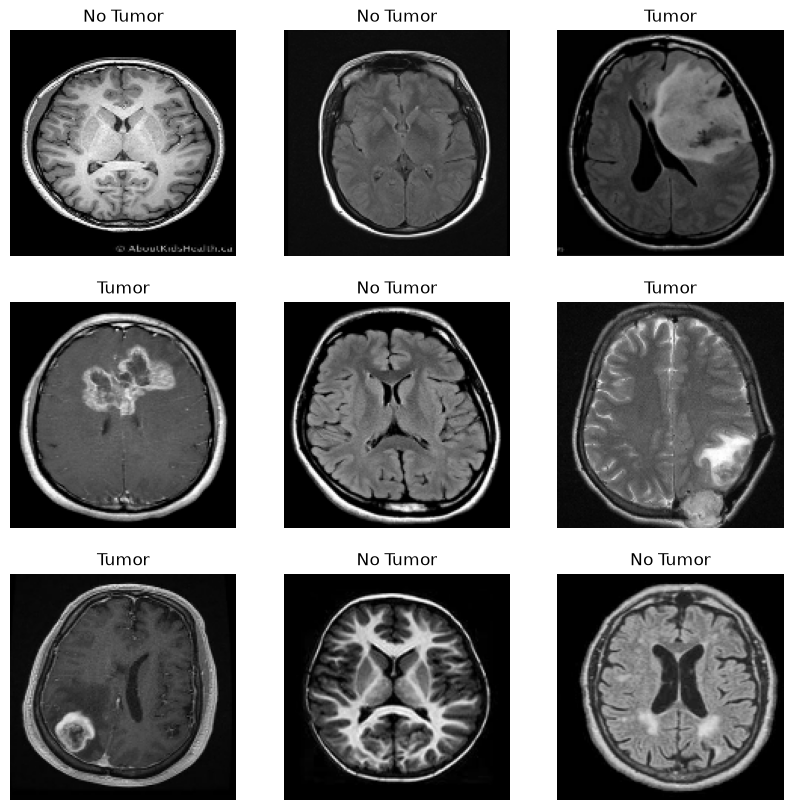

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Tumor" if class_names[labels[i]] == 'yes' else "No Tumor")
        plt.axis("off")
plt.show()

`train_ds.take(1)` grabs one batch of images. We draw 9 of them in a 3 x 3 grid with their correct label, to confirm the data loaded correctly.

In [7]:
train_labels = np.concatenate([y.numpy() for _, y in train_ds])
class_counts = np.bincount(train_labels)
total = class_counts.sum()

class_weight = {i: float(total / (len(class_counts) * class_counts[i])) for i in range(len(class_counts))}

print("Training images per class:", dict(zip(class_names, class_counts.tolist())))
print("Class weights:", {class_names[i]: round(w, 2) for i, w in class_weight.items()})

Training images per class: {'no': 68, 'yes': 108}
Class weights: {'no': 1.29, 'yes': 0.81}


We count the training images of each class. The rarer class (`no`) gets a **weight above 1** and the bigger class (`yes`) gets a **weight below 1**. These weights are given to `model.fit()` in the training step.

In [8]:
num_classes = 2

data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='data_augmentation')

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes)          # 2 outputs: score for 'no' and score for 'yes'
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,322 (5.98 MB)

 Trainable params: 1,568,322 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

epochs = 60
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weight,
    callbacks=[early_stop])

Epoch 1/60


c:\Users\aksha\OneDrive\Documents\python_exercises\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 638ms/step - accuracy: 0.5511 - loss: 0.7098 - val_accuracy: 0.6053 - val_loss: 0.5863
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 500ms/step - accuracy: 0.6534 - loss: 0.6627 - val_accuracy: 0.6842 - val_loss: 0.6250
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 499ms/step - accuracy: 0.7102 - loss: 0.6143 - val_accuracy: 0.6842 - val_loss: 0.5532
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 457ms/step - accuracy: 0.6420 - loss: 0.6451 - val_accuracy: 0.7632 - val_loss: 0.5112
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 476ms/step - accuracy: 0.7216 - loss: 0.6079 - val_accuracy: 0.7632 - val_loss: 0.5356
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 508ms/step - accuracy: 0.7273 - loss: 0.5727 - val_accuracy: 0.7895 - val_loss: 0.5660
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 500ms/step - accuracy: 0.7386 - loss: 0.5856 - val_accuracy: 0.6316 - val_loss: 0.6203
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 489ms/step - accuracy: 0.6307 - loss: 0.6161 - val_accuracy: 0.6316 - val_loss: 0.6106
Epo

`epochs = 60` is only the **maximum**. EarlyStopping will normally stop sooner.

`class_weight` applies the weights from step 6.

`validation_data=val_ds` checks the model on unseen validation images after every epoch. If `accuracy` keeps rising but `val_accuracy` does not, the model is overfitting.

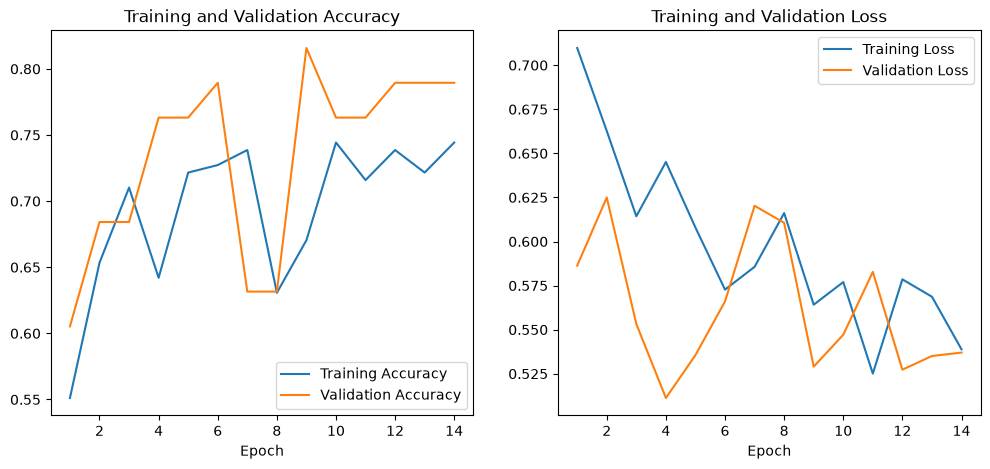

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)   # len(acc) = real number of epochs (EarlyStopping may stop early)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Epoch')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.xlabel('Epoch')
plt.title('Training and Validation Loss')
plt.show()

In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7436 - loss: 0.5268 
Test Accuracy: 0.7436
Test Loss: 0.5268


`model.evaluate` runs the model on every test image and reports the average loss and accuracy.

In [12]:
# True labels (test_ds is not shuffled, so the order matches the predictions)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

# Predictions: pick the class with the highest score
y_pred = np.argmax(model.predict(test_ds), axis=1)

target_names = ['No Tumor', 'Tumor']
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Classification Report:

              precision    recall  f1-score   support

    No Tumor       0.73      0.53      0.62        15
       Tumor       0.75      0.88      0.81        24

    accuracy                           0.74        39
   macro avg       0.74      0.70      0.71        39
weighted avg       0.74      0.74      0.73        39



**precision**: of the images the model called "Tumor", how many really were?

**recall**: of all the real tumor images, how many did the model find? For tumor detection, **recall of the Tumor class matters most**, because missing a real tumor is the worst mistake.

**f1-score**: a balance of precision and recall.

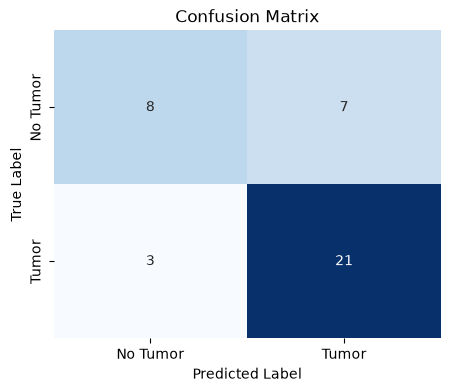

In [13]:
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [14]:
model.save('brain_tumor_classifier.keras')
print("Model saved as 'brain_tumor_classifier.keras'")

Model saved as 'brain_tumor_classifier.keras'


This creates the file `brain_tumor_classifier.keras`. Put it in the **same folder as `app.py`**. The saved file includes the augmentation and rescaling layers, so the app only needs to send the resized image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Raw model output (logits): [-0.468955    0.85706323]
Probabilities  ->  No Tumor: 20.98%   Tumor: 79.02%
This image most likely shows: Tumor (79.02% confidence)


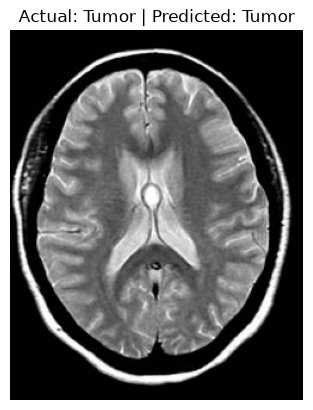

In [15]:
def preprocess_image(img):
    img = img.convert('RGB')
    arr = np.array(img, dtype=np.float32)
    arr = tf.image.resize(arr, (img_height, img_width)).numpy()   # same resize as training
    return np.expand_dims(arr, axis=0)                            # shape: (1, 150, 150, 3)

# Take the first image from the test folder (a tumor image) as an example
test_image_path = os.path.join(split_dir, 'test', 'yes', sorted(os.listdir(os.path.join(split_dir, 'test', 'yes')))[0])

img = Image.open(test_image_path)
img_array = preprocess_image(img)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print("Raw model output (logits):", predictions[0])
print("Probabilities  ->  No Tumor: {:.2f}%   Tumor: {:.2f}%".format(100 * score[0], 100 * score[1]))
print("This image most likely shows: {} ({:.2f}% confidence)"
      .format(target_names[np.argmax(score)], 100 * np.max(score)))

plt.imshow(img.convert('RGB'))
plt.title(f"Actual: Tumor | Predicted: {target_names[np.argmax(score)]}")
plt.axis('off')
plt.show()

`predictions` holds 2 raw scores. `tf.nn.softmax` turns them into probabilities that add up to 100%. The class with the higher probability is the prediction, and that probability is the **confidence**.

You can change `test_image_path` to any MRI image on your computer to try it.